# Borrowing strength: pretrain on abundant DHS indicators, transfer to a scarce one

*Companion to `dhs_displacement_demo.ipynb`. That notebook asked what DHS's fuzzy
coordinates cost an OlmoEarth covariate. This one asks how to make the most of the
labels you **do** have.*

**The situation.** Micronutrient biomarkers are collected in only a handful of DHS
surveys. But **child stunting and wasting** (plus wealth, under-5 mortality,
vaccination, water/sanitation…) are in essentially *every* geocoded DHS — tens of
thousands of clusters across dozens of countries and years. Can that abundance help
the scarce target?

**The idea: a shared representation learned from the abundant indicators.**
1. On the big pool of abundant labels, fit one **well-regularized predictor per
   indicator** from the frozen OlmoEarth embedding. Stacked, these give a compact
   representation — "EO-predicted stunting, wasting, wealth, U5MR" — that captures
   *which directions of the embedding matter for child-health outcomes* in these
   landscapes.
2. Fit a **small head** for the scarce micronutrient target on that representation.
   With only a handful of coefficients to learn, it generalizes from few labels.

This is **not fine-tuning OlmoEarth** (its weights stay frozen — see the
displacement notebook for the terminology). It is the linear, closed-form version of
a multi-task bottleneck, and it is where the abundant labels' volume would later
*justify* PEFT/fine-tuning the backbone.

**What decides whether transfer pays** is the **signal-to-noise regime** and the
**overlap** between tasks. EO explains only a modest share of child-health outcomes
(much is diet, infection, care). In that low-SNR, few-label world, learning 768
coefficients from scratch overfits noise, while a representation pretrained on
thousands of abundant labels already knows where to look — *for the drivers the
tasks share*. We measure both effects.

> ### ⚠️ What is real here
> - The **landscape and embeddings are real** (Sentinel-2 → OlmoEarth).
> - The **indicators and target are synthetic**, built from the real embeddings so we
>   can control (a) what the tasks share and (b) the SNR — both set to *realistic*
>   values (EO-explainable R² ≈ 0.35), not to flatter the method.
> - Evaluation is on a **spatially held-out** half of the landscape (west → east).
> - This demonstrates the *mechanism and its regime*, not epidemiology.


In [1]:
import os, time
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import RidgeCV
from sklearn.decomposition import PCA
from sklearn.metrics import r2_score

from olmoearth_pretrain_minimal import ModelID
from olmoe import load_encoder
from movement import load_landscape
import dhs, transfer

# --- config ---
VARIANT   = "TINY"            # fast + re-runnable; BASE for production (mechanism is variant-independent)
AOI       = (35.38, -14.83)   # Liwonde NP, Malawi
SIZE_PX   = 768               # 7.68 km window @10 m
STEP      = 20                # embedding-grid spacing (200 m)
K_LATENT  = 6                 # latent landscape drivers
NOISE_AB  = 1.2               # abundant-indicator noise sd (unit-variance signals)
NOISE_MIC = 1.36              # scarce-target noise sd -> EO-explainable R² ceiling ≈ 0.35
REP       = 4                 # noisy replicate clusters per cell for the abundant tasks
N_GRID    = [50, 100, 200, 400, 600]   # scarce micronutrient label counts
DRAWS     = 20                # random label draws averaged per N
ALPHAS    = np.logspace(1, 5, 30)      # ridge grid (floor 10) — same for every method/head
PRIVATE_W = [0.0, 0.3, 0.8, 1.5, 2.5]  # weight of the target's PRIVATE driver (overlap sweep)

if "HTTPS_PROXY" in os.environ:      # COG reads via GDAL/curl behind the proxy
    os.environ.setdefault("GDAL_HTTP_PROXY", os.environ["HTTPS_PROXY"])
    os.environ.setdefault("CURL_CA_BUNDLE", "/root/.ccr/ca-bundle.crt")
print("variant:", VARIANT)

/home/user/ai_assisted_research/olmoearth_spike/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


variant: TINY


## Step 1 — real landscape, embedding grid, latent drivers

Embed a dense grid once, then split the landscape **west (train) / east (test)** so
every result below is a spatial hold-out. The latent "drivers" are the embedding
projected on random orthonormal directions — deliberately *not* the top principal
components, because outcome-relevant axes need not be high-variance ones.

scene S2B_36LYJ_20210702_1_L2A | grid (36, 36, 192) embedded in 61s | west 648 / east 648 cells


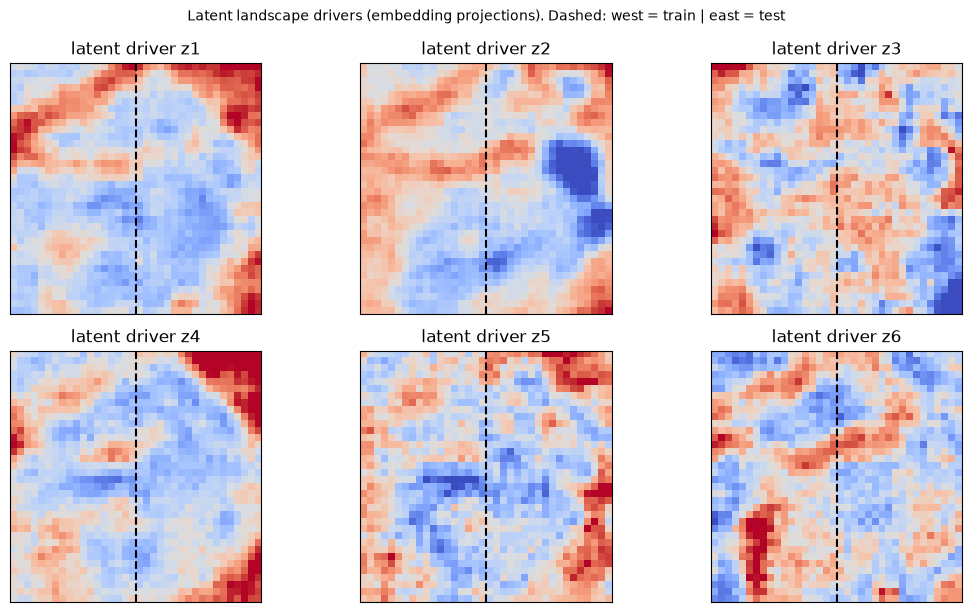

In [2]:
stack, meta = load_landscape(*AOI, size_px=SIZE_PX, n_dates=3)
model = load_encoder(getattr(ModelID, f"OLMOEARTH_V1_{VARIANT}"))
t0 = time.perf_counter()
E, rows, cols = dhs.embedding_grid(model, stack, meta["months"], step=STEP)
Ef = E.reshape(-1, E.shape[-1])
RR, CC = np.meshgrid(rows, cols, indexing="ij")
west = CC.ravel() < np.median(CC.ravel()); east = ~west
Z = transfer.latent_factors(Ef, k=K_LATENT, seed=0)
print(f"scene {meta['scene']} | grid {E.shape} embedded in {time.perf_counter()-t0:.0f}s "
      f"| west {west.sum()} / east {east.sum()} cells")

fig, axs = plt.subplots(2, 3, figsize=(11, 6.2))
for i, ax in enumerate(axs.ravel()):
    ax.imshow(Z[:, i].reshape(len(rows), len(cols)), cmap="coolwarm", vmin=-2.5, vmax=2.5)
    ax.axvline(len(cols)/2 - 0.5, color="k", lw=1.5, ls="--")
    ax.set_title(f"latent driver z{i+1}"); ax.set_xticks([]); ax.set_yticks([])
fig.suptitle("Latent landscape drivers (embedding projections). Dashed: west = train | east = test", fontsize=10)
plt.tight_layout(); plt.show()

## Step 2 — abundant indicators and the scarce target

Four **abundant** DHS-like indicators (stunting, wasting, wealth, U5MR) are noisy
combinations of drivers z1–z5. The **scarce** micronutrient target shares drivers
**z1, z2, z4** with them and also has a **private** driver **z6** no abundant task
uses — transfer can recover the shared part, never the private part (we vary its
weight in Step 6). Noise is set so EO explains ≈ 35% of the target: realistic, and
low enough that label scarcity bites.

abundant labels per task: 2592  |  scarce-target EO-explainable ceiling R² ≈ 0.35


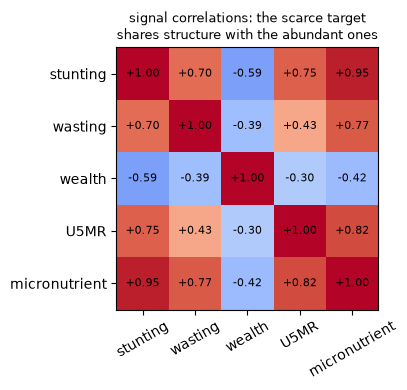

In [3]:
z1, z2, z3, z4, z5, z6 = [Z[:, i] for i in range(K_LATENT)]
S_ab = np.c_[ z1 + 0.6*z2 - 0.5*z3,          # "stunting"
              0.7*z1 - 0.5*z2 + 0.6*z4,      # "wasting"
             -0.4*z1 + 0.8*z3 + 0.5*z5,      # "wealth index"
              0.5*z2 + 0.6*z4 - 0.4*z5 ]     # "under-5 mortality"
AB_NAMES = ["stunting", "wasting", "wealth", "U5MR"]
def micro_signal(w_private):
    s = 0.8*z1 + 0.5*z2 + 0.6*z4 + w_private*z6
    return (s - s.mean()) / s.std()
s_mic = micro_signal(0.3)   # baseline: ~7% of the target's signal is private

def std_on(F, ref):   # standardize with ABUNDANT (west) statistics — available in practice
    mu, sd = F[ref].mean(0), F[ref].std(0) + 1e-9
    return (F - mu) / sd
Xs = std_on(Ef, west)

# abundant labels: REP noisy replicate clusters per west cell (many surveys/clusters)
rng = np.random.default_rng(1)
X_ab = np.repeat(Xs[west], REP, axis=0)
Y_ab = np.repeat(S_ab[west], REP, axis=0) + rng.normal(0, NOISE_AB, (west.sum()*REP, 4))
ceiling = 1 / (1 + NOISE_MIC**2)
print(f"abundant labels per task: {len(X_ab)}  |  scarce-target EO-explainable ceiling R² ≈ {ceiling:.2f}")

C = np.corrcoef(np.c_[S_ab, s_mic].T)
fig, ax = plt.subplots(figsize=(4.6, 4))
ax.imshow(C, cmap="coolwarm", vmin=-1, vmax=1)
labels = AB_NAMES + ["micronutrient"]
ax.set_xticks(range(5)); ax.set_yticks(range(5)); ax.set_xticklabels(labels, rotation=30); ax.set_yticklabels(labels)
for i in range(5):
    for j in range(5): ax.text(j, i, f"{C[i,j]:+.2f}", ha="center", va="center", fontsize=8)
ax.set_title("signal correlations: the scarce target\nshares structure with the abundant ones", fontsize=9.5)
plt.tight_layout(); plt.show()

## Step 3 — learn the shared representation from the abundant labels

One **CV-regularized ridge predictor per abundant indicator**, fit on the ~2,600
noisy labels each; stacked, they map the 768-dim embedding to **4 features**:
EO-predicted stunting, wasting, wealth, U5MR. We check they carry to the held-out
east half — and compare against fitting each indicator from the raw embedding.

*Methodological aside (kept because it cost us a day):* a gradient-trained shared
bottleneck (`transfer.train_trunk`) learned three of the four tasks but **dropped
"wealth"** — its drivers live on low-variance embedding directions whose weights it
under-regularized, so they overfit the west and did not transport. Giving each task
its own CV-chosen shrinkage fixes it. Per-task regularization is not a detail.

stunting  east R² (clean signal, mean of 5 draws):  raw-768 +0.73   predicted-4 +0.78
wasting   east R² (clean signal, mean of 5 draws):  raw-768 +0.77   predicted-4 +0.93
wealth    east R² (clean signal, mean of 5 draws):  raw-768 +0.57   predicted-4 +0.79
U5MR      east R² (clean signal, mean of 5 draws):  raw-768 +0.39   predicted-4 +0.85


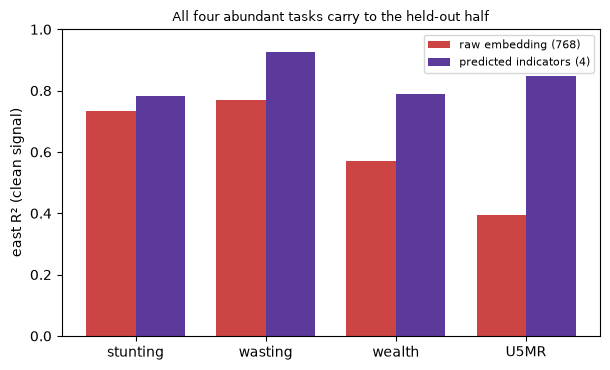

In [4]:
W = transfer.ridge_predictor_representation(X_ab, Y_ab, ALPHAS)   # (768 x 4)
feats = {"raw embedding (768)":   Xs,
         "PCA-8 (unsupervised)":  std_on(PCA(8).fit(Ef[west]).transform(Ef), west),
         "predicted indicators (4)": std_on(Xs @ W, west)}

def task_transport(F, seeds=range(9, 14)):   # mean over 5 noisy label draws
    out = np.zeros(4)
    for s in seeds:
        r = np.random.default_rng(s)
        for j in range(4):
            head = RidgeCV(alphas=ALPHAS).fit(F[west], S_ab[west, j] + r.normal(0, NOISE_AB, west.sum()))
            out[j] += r2_score(S_ab[east, j], head.predict(F[east]))
    return list(out / len(seeds))
tt_raw, tt_rep = task_transport(feats["raw embedding (768)"]), task_transport(feats["predicted indicators (4)"])
for n, a, b in zip(AB_NAMES, tt_raw, tt_rep): print(f"{n:9s} east R² (clean signal, mean of 5 draws):  raw-768 {a:+.2f}   predicted-4 {b:+.2f}")

x = np.arange(4); w_ = 0.38
fig, ax = plt.subplots(figsize=(6.2, 3.8))
ax.bar(x - w_/2, tt_raw, w_, color="#c44", label="raw embedding (768)")
ax.bar(x + w_/2, tt_rep, w_, color="#5B3A9B", label="predicted indicators (4)")
ax.set_xticks(x); ax.set_xticklabels(AB_NAMES); ax.set_ylim(0, 1); ax.set_ylabel("east R² (clean signal)")
ax.set_title("All four abundant tasks carry to the held-out half", fontsize=9.5); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

## Step 4 — the transfer experiment

Fit the scarce micronutrient head on **N** randomly drawn west clusters (each a
noisy label), evaluate on all east clusters, repeat `DRAWS` times. Three
representations, the **same** regularized ridge head (grid floor α ≥ 10, chosen by
CV) for each — so only the representation differs:

- **raw embedding (768)** — from scratch;
- **PCA-8** — unsupervised compression (no labels);
- **predicted indicators (4)** — learned from the abundant labels.

    N |        raw embedding (768) |       PCA-8 (unsupervised) |   predicted indicators (4)
   50 | +0.209 ± 0.10           | +0.090 ± 0.18           | +0.348 ± 0.04          
  100 | +0.146 ± 0.19           | +0.109 ± 0.25           | +0.348 ± 0.04          
  200 | +0.240 ± 0.10           | +0.225 ± 0.09           | +0.367 ± 0.03          
  400 | +0.277 ± 0.08           | +0.267 ± 0.08           | +0.369 ± 0.02          
  600 | +0.320 ± 0.05           | +0.313 ± 0.06           | +0.379 ± 0.03          


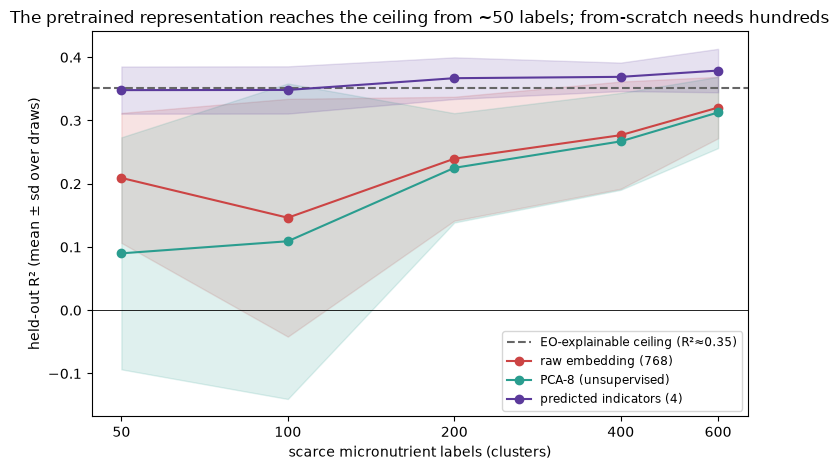

In [5]:
def run(F, y, N, draws=DRAWS):
    pool = np.where(west)[0]; out = []
    for d in range(draws):
        r = np.random.default_rng(50 + d)
        tr = r.choice(pool, N, replace=False)
        head = RidgeCV(alphas=ALPHAS).fit(F[tr], y[tr] + r.normal(0, NOISE_MIC, N))
        y_te = y[east] + r.normal(0, NOISE_MIC, east.sum())     # noisy observed target
        out.append(r2_score(y_te, head.predict(F[east])))
    return np.mean(out), np.std(out)

res = {k: np.array([run(F, s_mic, N) for N in N_GRID]) for k, F in feats.items()}
print(f"{'N':>5} | " + " | ".join(f"{k:>26s}" for k in feats))
for i, N in enumerate(N_GRID):
    print(f"{N:5d} | " + " | ".join(f"{res[k][i,0]:+.3f} ± {res[k][i,1]:.2f}          " for k in feats))

colors = {"raw embedding (768)": "#c44", "PCA-8 (unsupervised)": "#2A9D8F", "predicted indicators (4)": "#5B3A9B"}
fig, ax = plt.subplots(figsize=(7.5, 4.8))
ax.axhline(ceiling, ls="--", color="0.4", label=f"EO-explainable ceiling (R²≈{ceiling:.2f})")
for k, arr in res.items():
    ax.plot(N_GRID, arr[:,0], "-o", color=colors[k], label=k)
    ax.fill_between(N_GRID, arr[:,0]-arr[:,1], arr[:,0]+arr[:,1], color=colors[k], alpha=0.15)
ax.axhline(0, color="k", lw=0.6); ax.set_xscale("log"); ax.set_xticks(N_GRID); ax.set_xticklabels(N_GRID); ax.minorticks_off()
ax.set_xlabel("scarce micronutrient labels (clusters)"); ax.set_ylabel("held-out R² (mean ± sd over draws)")
ax.set_title("The pretrained representation reaches the ceiling from ~50 labels; from-scratch needs hundreds")
ax.legend(fontsize=8.5, loc="lower right"); plt.tight_layout(); plt.show()

## Step 5 — the label-scarce regime up close

At **N = 100** clusters (a realistic count for a micronutrient module in one
country), compare the three heads — mean **and spread** across label draws. Lower
variance matters as much as the mean: it is the difference between a covariate you
can trust in a new country and one that depends on which clusters you happened to
get.

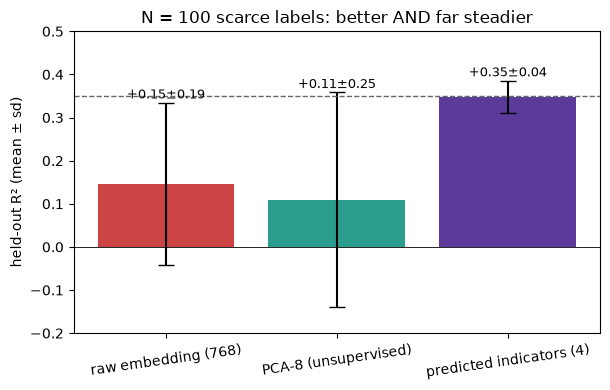

In [6]:
i100 = N_GRID.index(100)
names = list(feats); means = [res[k][i100,0] for k in names]; sds = [res[k][i100,1] for k in names]
fig, ax = plt.subplots(figsize=(6.2, 4))
ax.bar(names, means, yerr=sds, capsize=6, color=[colors[k] for k in names])
ax.axhline(ceiling, ls="--", color="0.4", lw=1); ax.axhline(0, color="k", lw=0.6); ax.set_ylim(-0.2, 0.5)
ax.set_ylabel("held-out R² (mean ± sd)"); ax.set_title("N = 100 scarce labels: better AND far steadier")
for i, (m_, s_) in enumerate(zip(means, sds)): ax.text(i, m_ + s_ + 0.01, f"{m_:+.2f}±{s_:.2f}", ha="center", fontsize=9)
plt.xticks(rotation=8); plt.tight_layout(); plt.show()

## Step 6 — the honest boundary: how much must the tasks overlap?

Transfer can only recover the part of the scarce target's EO-explainable signal that
lies in the span of what the abundant indicators predict. We sweep the weight of the
target's **private** driver (z6) — i.e. the share of its signal *no* abundant task
carries — and compare the pretrained representation (at N = 100 and 600) with
from-scratch ridge at N = 600.

private share   0%:  predicted-4 @N100 +0.344 | @N600 +0.362 | raw-768 @N600 +0.304


private share   7%:  predicted-4 @N100 +0.348 | @N600 +0.379 | raw-768 @N600 +0.320


private share  34%:  predicted-4 @N100 +0.281 | @N600 +0.323 | raw-768 @N600 +0.268


private share  64%:  predicted-4 @N100 +0.127 | @N600 +0.166 | raw-768 @N600 +0.129


private share  83%:  predicted-4 @N100 -0.067 | @N600 -0.044 | raw-768 @N600 -0.019


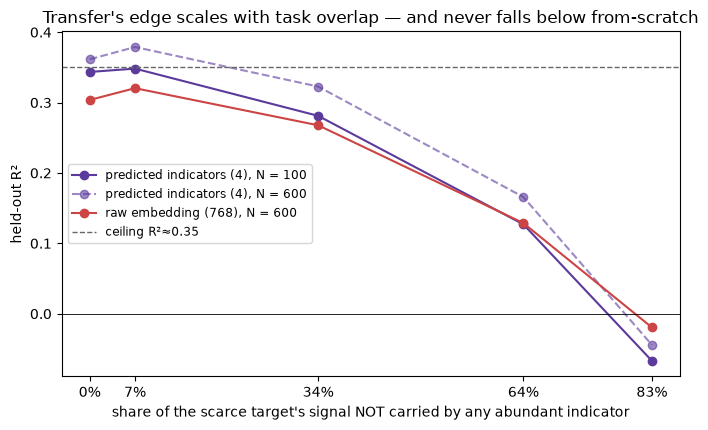

In [7]:
priv_share, rep100, rep600, raw600 = [], [], [], []
for w in PRIVATE_W:
    s = micro_signal(w)
    priv_share.append(w**2 / (0.64 + 0.25 + 0.36 + w**2))
    rep100.append(run(feats["predicted indicators (4)"], s, 100)[0])
    rep600.append(run(feats["predicted indicators (4)"], s, 600)[0])
    raw600.append(run(feats["raw embedding (768)"], s, 600)[0])
    print(f"private share {priv_share[-1]:4.0%}:  predicted-4 @N100 {rep100[-1]:+.3f} | @N600 {rep600[-1]:+.3f} | raw-768 @N600 {raw600[-1]:+.3f}")

fig, ax = plt.subplots(figsize=(7, 4.4))
ax.plot(priv_share, rep100, "-o", color="#5B3A9B", label="predicted indicators (4), N = 100")
ax.plot(priv_share, rep600, "--o", color="#5B3A9B", alpha=0.6, label="predicted indicators (4), N = 600")
ax.plot(priv_share, raw600, "-o", color="#c44", label="raw embedding (768), N = 600")
ax.axhline(ceiling, ls="--", color="0.4", lw=1, label=f"ceiling R²≈{ceiling:.2f}"); ax.axhline(0, color="k", lw=0.6)
ax.set_xlabel("share of the scarce target's signal NOT carried by any abundant indicator")
ax.set_ylabel("held-out R²"); ax.set_title("Transfer's edge scales with task overlap — and never falls below from-scratch")
ax.set_xticks(priv_share); ax.set_xticklabels([f"{p:.0%}" for p in priv_share]); ax.legend(fontsize=8.5)
plt.tight_layout(); plt.show()

## What this means

**Transfer from abundant indicators is a real lever — in exactly the regime you are
in.** With realistic SNR and ≲ 200 micronutrient clusters, a 4-coefficient head on
the pretrained representation reaches the **EO-explainable ceiling from ~50 labels,
with a quarter of the variance** of fitting 768 coefficients from scratch — which
is still short of the ceiling at 600 labels. Unsupervised PCA-8 lags because it keeps
the highest-**variance** directions, not the outcome-**relevant** ones; that
relevance is precisely what the abundant labels buy.

**The boundary is task overlap.** The representation can only carry the drivers the
abundant indicators share with the target. As the target's private share grows, the
edge shrinks — near-ceiling below ~10% private, parity around ~60% — but it never
drops *below* from-scratch, because a private driver that EO barely explains is just
as hard to learn either way. For real DHS this is the empirical question to answer
first: **how much of micronutrient status's EO-explainable signal is shared with
stunting/wasting/wealth?** Plausibly a lot (shared agroecological and poverty
drivers), but measure it.

**Design lessons that carry to real DHS.**
- **Multiple indicators, not one.** A representation built from a single indicator
  collapses to that one direction; several force it to span the shared drivers.
- **Regularize each task on its own.** A jointly-trained bottleneck dropped the task
  whose drivers live on low-variance directions; per-task CV shrinkage kept all four.
- **Standardize compressed features with the abundant data's statistics**, and
  floor the head's regularization — a few-parameter head with 50 noisy labels can
  otherwise pick a near-OLS penalty and extrapolate wildly.
- **Where the volume justifies it, go further:** the abundant labels are what would
  make PEFT/fine-tuning OlmoEarth itself worthwhile — adapting the backbone to
  child-health-relevant structure — with the scarce target still riding on top.
- **Compose with displacement handling** (previous notebook): use displacement-
  matched buffer or areal features throughout, for the abundant *and* scarce tasks.

**Honest caveats.** Synthetic indicators/target on real embeddings; one landscape
window; TINY variant; the shared/private split is a design choice. What transfers to
real data is the *shape* of the curves and the regime boundary, not the exact R²
values — re-estimate them with real stunting/wasting labels and a leave-one-country-
out split.

saved outputs/dhs_transfer_figure.png


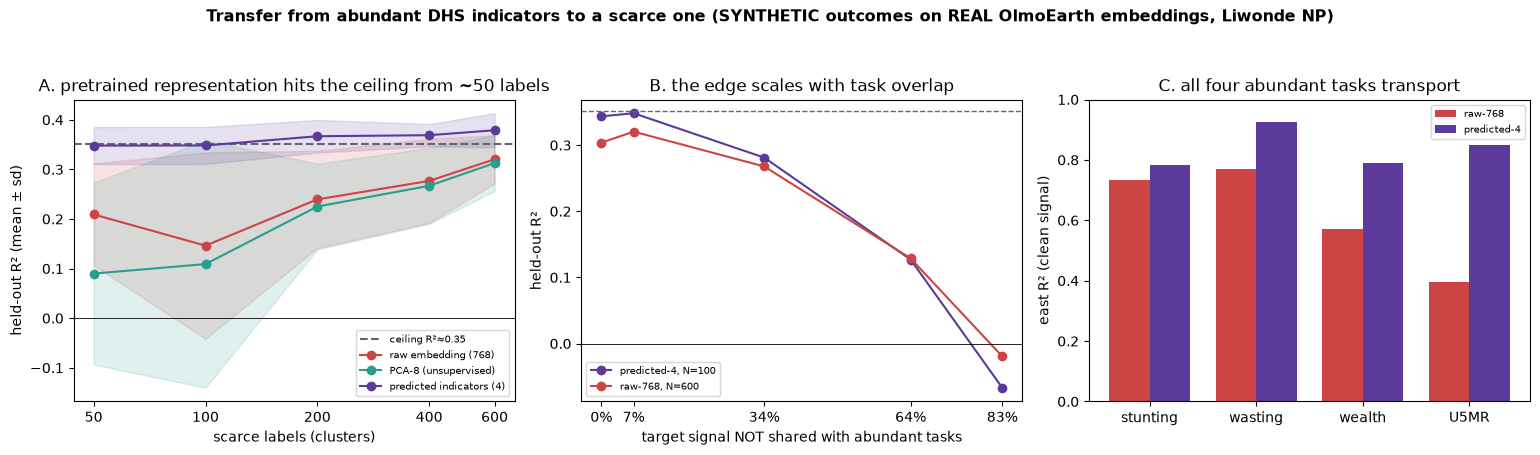

In [8]:
# Compact summary figure for the repo/PR.
fig, axs = plt.subplots(1, 3, figsize=(15.5, 4.6))
fig.suptitle("Transfer from abundant DHS indicators to a scarce one (SYNTHETIC outcomes on REAL OlmoEarth embeddings, Liwonde NP)",
             fontsize=11.5, fontweight="bold")
axs[0].axhline(ceiling, ls="--", color="0.4", label=f"ceiling R²≈{ceiling:.2f}")
for k, arr in res.items():
    axs[0].plot(N_GRID, arr[:,0], "-o", color=colors[k], label=k)
    axs[0].fill_between(N_GRID, arr[:,0]-arr[:,1], arr[:,0]+arr[:,1], color=colors[k], alpha=0.15)
axs[0].axhline(0, color="k", lw=0.6); axs[0].set_xscale("log"); axs[0].set_xticks(N_GRID); axs[0].set_xticklabels(N_GRID); axs[0].minorticks_off()
axs[0].set_xlabel("scarce labels (clusters)"); axs[0].set_ylabel("held-out R² (mean ± sd)")
axs[0].set_title("A. pretrained representation hits the ceiling from ~50 labels"); axs[0].legend(fontsize=7.5, loc="lower right")
axs[1].plot(priv_share, rep100, "-o", color="#5B3A9B", label="predicted-4, N=100")
axs[1].plot(priv_share, raw600, "-o", color="#c44", label="raw-768, N=600")
axs[1].axhline(ceiling, ls="--", color="0.4", lw=1); axs[1].axhline(0, color="k", lw=0.6)
axs[1].set_xticks(priv_share); axs[1].set_xticklabels([f"{p:.0%}" for p in priv_share])
axs[1].set_xlabel("target signal NOT shared with abundant tasks"); axs[1].set_ylabel("held-out R²")
axs[1].set_title("B. the edge scales with task overlap"); axs[1].legend(fontsize=7.5)
axs[2].bar(x - w_/2, tt_raw, w_, color="#c44", label="raw-768"); axs[2].bar(x + w_/2, tt_rep, w_, color="#5B3A9B", label="predicted-4")
axs[2].set_xticks(x); axs[2].set_xticklabels(AB_NAMES); axs[2].set_ylim(0, 1); axs[2].set_ylabel("east R² (clean signal)")
axs[2].set_title("C. all four abundant tasks transport"); axs[2].legend(fontsize=7.5)
plt.tight_layout(rect=[0,0,1,0.93])
fig.savefig("outputs/dhs_transfer_figure.png", dpi=150, bbox_inches="tight", facecolor="white")
print("saved outputs/dhs_transfer_figure.png")
plt.show()